In [2]:
# ================================================================
# Import required libraries
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.optimize import brentq
from numba import njit
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

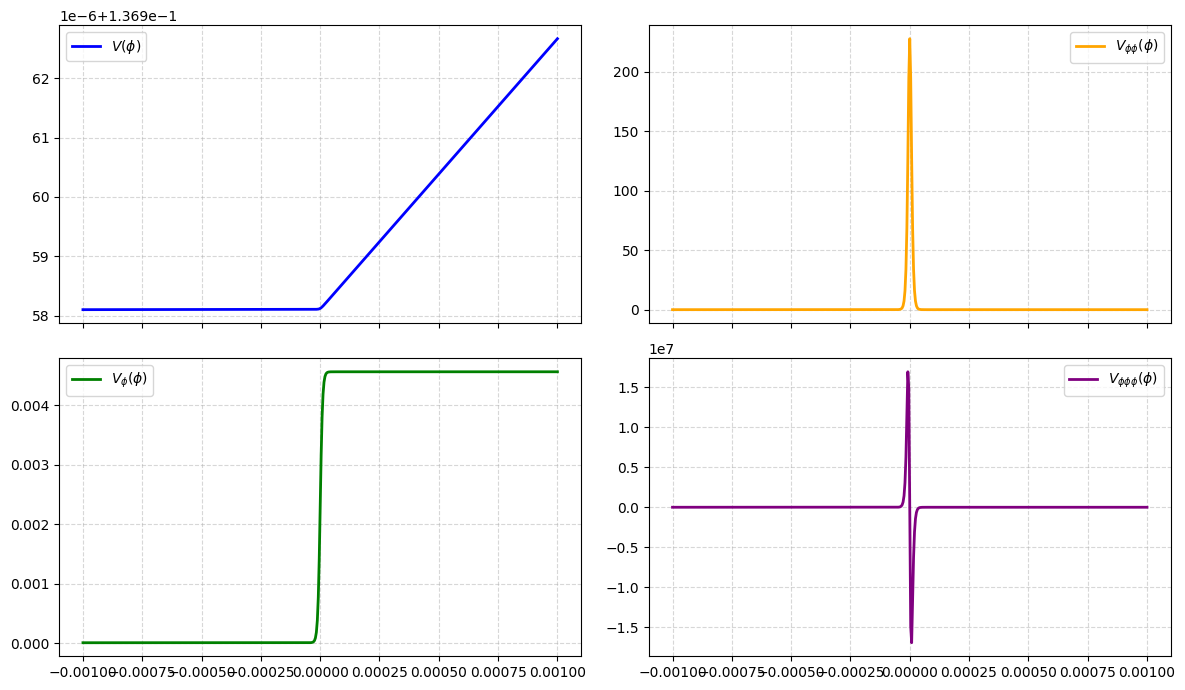

In [5]:
# ================================================================
# 1. Inflationary Potential and its Derivatives
# ================================================================
# The model is based on a Starobinsky potential with a localized feature define in equation (4.1).
# The feature is created using a single tanh(x) step in the first derivative 
# of the potential, which is numerically more efficient than connecting linear functions.

delta = 10**5
V0 = 0.1369581204194972
Ap = 0.1 * V0 / 3
Am = Ap * 1.139455e-3
fT = 0

slope_avg = (Ap + Am) / 2.0
slope_diff = (Ap - Am) / 2.0

@njit
def log_cosh(x):
    """Numerically stable log(cosh(x)) for the potential integration."""
    return np.abs(x) - np.log(2) + np.log1p(np.exp(-2 * np.abs(x)))

@njit
def V(phi):
    """Inflationary potential V(φ)."""
    X = phi - fT
    return V0 + slope_avg * X + (slope_diff / delta) * log_cosh(delta * X)

@njit
def V_phi(phi):
    """First derivative of the potential with respect to the field φ."""
    X = phi - fT
    return slope_avg + slope_diff * np.tanh(delta * X)

@njit
def V_phiphi(phi):
    """Second derivative of the potential with respect to φ."""
    X = phi - fT
    tanh_val = np.tanh(delta * X)
    return slope_diff * delta * (1 - tanh_val**2)

@njit
def V_phiphiphi(phi):
    """Third derivative of the potential with respect to φ."""
    X = phi - fT
    tanh_val = np.tanh(delta * X)
    return -2 * slope_diff * delta**2 * (tanh_val - tanh_val**3)



# ================================================================
# Plot the inflationary potential and its derivatives
# ================================================================
phi_grid = np.linspace(-0.001, 0.001, 499)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes[0,0].plot(phi_grid, V(phi_grid), color='blue', linewidth=2, label=r'$V(\phi)$')
axes[0,0].grid(True, linestyle='--', alpha=0.5); axes[0,0].legend()

axes[1,0].plot(phi_grid, V_phi(phi_grid), color='green', linewidth=2, label=r'$V_{\phi}(\phi)$')
axes[1,0].grid(True, linestyle='--', alpha=0.5); axes[1,0].legend()

axes[0,1].plot(phi_grid, V_phiphi(phi_grid), color='orange', linewidth=2, label=r'$V_{\phi\phi}(\phi)$')
axes[0,1].grid(True, linestyle='--', alpha=0.5); axes[0,1].legend()

axes[1,1].plot(phi_grid, V_phiphiphi(phi_grid), color='purple', linewidth=2, label=r'$V_{\phi\phi\phi}(\phi)$')
axes[1,1].grid(True, linestyle='--', alpha=0.5); axes[1,1].legend()

plt.tight_layout()
plt.show()

In [4]:
# ================================================================
# 2. Background Evolution Solver
# ================================================================
# We solve the background kinematics with respect to the number of e-folds (N).
# Variables:
#   fc[0] = phi   (scalar field)
#   fc[1] = phi_N (derivative of phi with respect to N, i.e., dφ/dN)

def background_eom(N, fc):
    """Klein-Gordon equations mapped to e-fold time N."""
    phi = fc[0]
    phi_N = fc[1]
    
    # First Hubble slow-roll parameter: ε₁ = (1/2)(dφ/dN)²
    eps1 = 0.5 * phi_N**2 
    
    dfc_dN = np.zeros(2)
    dfc_dN[0] = phi_N
    dfc_dN[1] = (V_phi(phi) / V(phi) + phi_N) * (eps1 - 3.0)
    return dfc_dN

# Initial conditions (Slow-roll approximation used for initial velocity)
phi_in = 0.4
eps1_in = 0.00054655
phi_N_in = -np.sqrt(2 * eps1_in)
fin = [phi_in, phi_N_in]

# Integration range in e-folds
N_start = 0 
N_end = 25

# Solve the ODE. max_step is kept small to guarantee high-resolution interpolation later.
solb = solve_ivp(background_eom, (N_start, N_end), fin, method='DOP853', max_step=0.0001)

In [6]:
# ================================================================
# 3. Extract Background Quantities and Create Interpolators
# ================================================================
# The time variable 't_bg' represents the number of e-folds (N).
t_bg = np.ascontiguousarray(solb.t) 
phi_values = solb.y[0]    # φ(N)
phi_N_values = solb.y[1]  # dφ/dN

# Potential evaluated on the background
V_vals = V(phi_values)
V_phi_vals = V_phi(phi_values)
V_phiphi_vals = V_phiphi(phi_values)

# Higher order derivatives of the field with respect to N
phi_NN_values = (V_phi_vals / V_vals + phi_N_values) * (phi_N_values**2 / 2 - 3)
phi_NNN_values = (
    (phi_N_values * V_phiphi_vals/V_vals - phi_N_values*(V_phi_vals/V_vals)**2 + phi_NN_values) 
    * (phi_N_values**2/2 - 3)
    + (V_phi_vals/V_vals + phi_N_values) * (phi_N_values * phi_NN_values)
)

# Slow-roll parameters
eps1_values = np.ascontiguousarray(phi_N_values**2 / 2)  
H_values = np.ascontiguousarray(np.sqrt(V_vals / (3 - eps1_values)))  
eps2_values = 2 * phi_NN_values / phi_N_values
eps2_N_values = -2 * phi_NN_values**2 / phi_N_values**2 + 2 * phi_NNN_values / phi_N_values

# z''/(a^2 H^2 z) term needed for the exact Mukhanov–Sasaki mode equation
zppoz_values = np.ascontiguousarray(
    2 - eps1_values + 3/2 * eps2_values + 1/4 * eps2_values**2 - 1/2 * eps1_values * eps2_values + 1/2 * eps2_N_values
)

# Create 1D interpolators for continuous access to background parameters
H_interp = interp1d(t_bg, H_values, kind='linear', fill_value="extrapolate")
eps1_interp = interp1d(t_bg, eps1_values, kind='linear', fill_value="extrapolate")
eps2_interp = interp1d(t_bg, eps2_values, kind='linear', fill_value="extrapolate")
zppoz_interp = interp1d(t_bg, zppoz_values, kind='linear', fill_value="extrapolate")
phi_interp = interp1d(t_bg, phi_values, kind='linear', fill_value="extrapolate")
phi_N_interp = interp1d(t_bg, phi_N_values, kind='linear', fill_value="extrapolate")
phi_NN_interp = interp1d(t_bg, phi_NN_values, kind='linear', fill_value="extrapolate")

# Store target values at the end of inflation
eps1_end = eps1_values[-1]
phi_N_end = phi_N_values[-1]
phi_NN_end = phi_NN_values[-1]


# ================================================================
# 4. Continuous Sensitivity Analysis (CSA) Framework
# ================================================================
# In the dN formalism, variations in the e-folds depend on the sensitivities 
# of final state variables to initial conditions.
# Here we calculate the Jacobian (J) and Hessian (H) flows.

def csa_system(N, y_flat, k):
    """
    Integrates the Jacobian matrix J (first-order CSA) and Hessian H (second-order CSA).
    y_flat contains 12 components: 4 for the 2x2 Jacobian, 8 for the 2x2x2 Hessian.
    """
    J = y_flat[0:4].reshape((2, 2))
    H = y_flat[4:12].reshape((2, 2, 2))
    
    # Extract precise background parameters
    phi = float(phi_interp(N))
    phi_N = float(phi_N_interp(N))

    V_val = V(phi)
    V_phi_val = V_phi(phi)
    V_phiphi_val = V_phiphi(phi)
    V_phiphiphi_val = V_phiphiphi(phi)

    eps = 0.5 * phi_N**2
    g = V_phi_val / V_val
    gp = (V_phiphi_val * V_val - V_phi_val**2) / (V_val**2)
    gpp = (V_phiphiphi_val/V_val) - 3.0*(V_phiphi_val*V_phi_val)/(V_val**2) + 2.0*(V_phi_val**3)/(V_val**3)

    # Local Stability Matrix (A) based on equation (C.7)
    A = np.array([
        [0.0, 1.0],
        [-(3.0 - eps) * gp,  phi_N * (phi_N + g) - (3.0 - eps)]
    ])

    # For full gradient interactions, map initial perturbations directly to J elements according to the identification (4.39)
    C1 = J[0, 0] / phi_N
    C2 = J[0, 1] / phi_N
    C_vec = np.array([C1, C2])

    a_t = a(N)
    source_factor = (eps - 3.0) / V_val * (k / a_t)**2 * phi_N

    # Forcing Matrix (Gamma) for the Jacobian based on equation (C.7)
    Gamma = np.array([
        [0.0, 0.0],
        [source_factor * C1, source_factor * C2]
    ])

    # First-order ODE: dJ/dN = A*J + Gamma (equation (C.5))
    dJ_dN = np.matmul(A, J) + Gamma

    # Third-order Background Tensor (calA) for the Hessian based on equation (C.10)
    calA = np.zeros((2, 2, 2))
    calA[1, 0, 0] = (eps - 3.0) * gpp
    calA[1, 0, 1] = phi_N * gp
    calA[1, 1, 0] = phi_N * gp
    calA[1, 1, 1] = g + 3.0 * phi_N
    
    # Second-order Forcing Tensor (Omega) given in equation (C.11)
    Omega = np.zeros((2, 2, 2))
    Bj = (k**2 / (a_t**2 * V_val)) * np.array([-g * phi_N * (eps - 3.0), 3.0 * (eps - 1.0)])
    B_dot_J = np.matmul(Bj, J)
    
    for a_idx in range(2):
        for b_idx in range(2):
            Omega[1, a_idx, b_idx] = C_vec[b_idx] * B_dot_J[a_idx] + C_vec[a_idx] * B_dot_J[b_idx]

    # Second-order ODE: dH/dN = A*H + calA*J*J + Omega (equation (C.9))
    dH_dN = np.einsum('ij,jab->iab', A, H) + np.einsum('ijk,ja,kb->iab', calA, J, J) + Omega

    return np.concatenate((dJ_dN.flatten(), dH_dN.flatten()))

In [16]:
# ================================================================
# 5. Pre-computations for the Power Spectrum
# ================================================================
# The scale factor formula: a(N) = a_end * exp(N - N_end)
a_end = 3e7
def a(N):
    return a_end * np.exp(N - N_end)

# Wavenumber grid
k_ini = 10**(-0.5)
k_fin = 10**(2.0)
nop = 320
kk = [k_ini * (k_fin / k_ini)**(i / (nop - 1)) for i in range(nop)]

# Horizon-crossing times: k = a(N) * H(N)
n_hc = []
for item in kk:
    try:
        val = brentq(lambda N: item - a(N) * H_interp(N), N_start + 0.1, N_end - 0.1)
        n_hc.append(val)
    except ValueError:
        n_hc.append(N_start + 1)
        
# Mukhanov–Sasaki starts ~4 e-folds before horizon crossing
n_in = [x - 4 for x in n_hc]

# Compute Conformal Time (tau) mapping exactly
a_bg = a(t_bg)
tau_exact_bg = cumulative_trapezoid(1.0 / (a_bg * H_values), t_bg, initial=0.0)
tau_exact_interp = interp1d(t_bg, tau_exact_bg, kind='cubic', bounds_error=False, fill_value="extrapolate")

# Mukhanov-Sasaki equation for exact evolution
# This equation corresponds to Eq. (C.3) of arXiv:2301.03600 and is written for the canonical variable \bar{v}_k.
# This is used to evaluate exact power spectrum
@njit
def MS_equation(N, v, k, t_bg_arr, eps1_bg_arr, H_bg_arr, zppoz_bg_arr, N_end_val, a_end_val):
    vc = v[0]
    vcp = v[1]
    
    eps1_t = np.interp(N, t_bg_arr, eps1_bg_arr)
    H_t = np.interp(N, t_bg_arr, H_bg_arr)
    zppoz_t = np.interp(N, t_bg_arr, zppoz_bg_arr)
    a_t = a_end_val * np.exp(N - N_end_val)
    
    damping = (1.0 - eps1_t) - (2j * k) / (a_t * H_t)
    
    dvcdt = vcp
    dvcpdt = -damping * vcp + zppoz_t * vc
    res = np.empty(2, dtype=np.complex128)
    res[0] = dvcdt
    res[1] = dvcpdt
    return res

In [17]:
# ================================================================
# 6. Main Evaluation Loop over k-modes
# ================================================================
def calculate_powers_for_k(i, k):
    """
    Evaluates:
      1. Exact Power Spectrum via direct MS equation integration.
      2. Power Spectrum via δN with full spatial gradients (CSA method).
      3. Equilateral Non-Gaussianity (f_NL) using the second-order CSA Hessian.
    """
    # ----------------------------------------------------------------
    # A. Exact Mukhanov-Sasaki Integration
    # ----------------------------------------------------------------
    solf = solve_ivp(
        lambda N, v: MS_equation(N, v, k, t_bg, eps1_values, H_values, zppoz_values, N_end, a_end),
        (n_in[i], N_end - 0.01), [1.+0.j, 0.+0.j], method='DOP853', rtol=1e-9, atol=1e-10
    )
    v_end = solf.y[0][-1]
    power_exact_val = k**2 * np.abs(v_end)**2 / (8 * np.pi**2 * eps1_end * a_end**2)

    # ----------------------------------------------------------------
    # B. Match Background State at Horizon Crossing (sigma = 1)
    # ----------------------------------------------------------------
    sigma = 1 # Matching standard: k = sigma * a * H
    n_match = max(N_start, brentq(lambda N: k - sigma * a(N) * H_interp(N), n_in[i], N_end - 0.01))
    
    phi_N_m = float(phi_N_interp(n_match))
    H_m = H_interp(n_match)
    a_m = a(n_match)
    eta_m = eps2_interp(n_match)
    z_m = a_m * phi_N_m
    aH_m = a_m * H_m
    tau_m = tau_exact_interp(n_match)

    # Extract mode and mode-derivative precisely at matching time
    v_bar_interp = interp1d(solf.t, solf.y[0], kind='cubic', bounds_error=False, fill_value="extrapolate")
    vp_bar_interp = interp1d(solf.t, solf.y[1], kind='cubic', bounds_error=False, fill_value="extrapolate")
    vb_m = v_bar_interp(n_match)
    vbp_m = aH_m * vp_bar_interp(n_match)

    # Convert to positive frequency and standard curvature perturbations
    v_match = (vb_m / np.sqrt(2*k)) * np.exp(-1j * k * tau_m)
    vp_match = ((vbp_m - 1j * k * vb_m) / np.sqrt(2 * k)) * np.exp(-1j * k * tau_m)

    R_match = v_match / z_m
    zp_over_z = (1.0 + 0.5 * eta_m) * aH_m
    Rp_match = (vp_match - v_match * zp_over_z) / z_m

    delta_X = np.array([R_match, Rp_match], dtype=np.complex128)
    
    # ----------------------------------------------------------------
    # C. Execute CSA Framework for δN Observables
    # ----------------------------------------------------------------
    # 12-component initial vector (based on equation (C.6) and the fact that all Hessian vanish at matching surface)
    y0_flat = np.zeros(12)
    y0_flat[0:4] = [phi_N_m, 0, phi_NN_interp(n_match), phi_N_m / aH_m]
    
    solution = solve_ivp(
        csa_system, (n_match, N_end), y0_flat,
        method='DOP853', args=(k,), rtol=1e-12, atol=1e-12
    )
    
    # Extract final sensitivities
    J_end = solution.y[0:4, -1].reshape((2, 2))
    H_end = solution.y[4:12, -1].reshape((2, 2, 2))
    
    # Project Jacobian onto variations of N
    N1 = - J_end[0, 0] / phi_N_end
    N2 = - J_end[0, 1] / phi_N_end
    grad = np.array([N1, N2])

    # Final δN Power Spectrum based on equation (C.15)
    prefactor = (k**3 / (2 * np.pi**2))
    R_end = np.dot(delta_X, grad)
    power_dN_val = prefactor * np.abs(R_end)**2
    
    # Covariance Matrix needed for Non-Gaussianity (equation (2.21))
    P_matrix = prefactor * np.real(np.outer(delta_X, np.conjugate(delta_X)))

    # ----------------------------------------------------------------
    # D. Second-Order CSA calculation of f_NL (Equilateral)
    # ----------------------------------------------------------------
    J1 = J_end[0, :]
    J2 = J_end[1, :]
    
    # Matrix M defined in equation (C.16)
    M_ab = np.zeros((2, 2))
    for a_idx in range(2):
        for b_idx in range(2):
            M_ab[a_idx, b_idx] = (
                H_end[0, a_idx, b_idx] 
                - (2.0 / phi_N_end) * J2[a_idx] * J1[b_idx] 
                + (phi_NN_end / phi_N_end**2) * J1[a_idx] * J1[b_idx]
            )
    
    # Numerator and denominator of fNL formula (C.17)
    numerator = np.einsum('ab,c,d,ac,bd->', M_ab, J1, J1, P_matrix, P_matrix)
    denominator = np.einsum('e,f,ef->', J1, J1, P_matrix)
    
    fNL_val = - (5.0 * phi_N_end / 6.0) * (numerator / denominator**2) # Equation (C.17)

    return power_exact_val, power_dN_val, fNL_val

In [18]:
# ============================================================
# Execute calculation parallelly across all CPU cores
# ============================================================
# Each k-mode is fully independent. We therefore distribute the workload across all available CPU cores.
results = Parallel(n_jobs=-1)(delayed(calculate_powers_for_k)(i, k) for i, k in enumerate(tqdm(kk)))

# Unpack the returned variables into arrays
power_exact_array = np.array([r[0] for r in results])
power_dN_array = np.array([r[1] for r in results])
fNL_array = np.array([r[2] for r in results])

  0%|          | 0/320 [00:00<?, ?it/s]

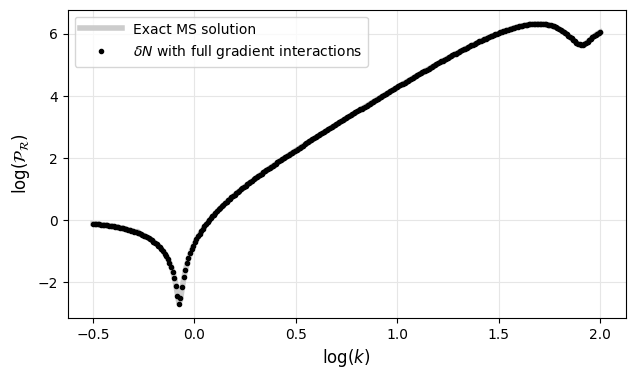

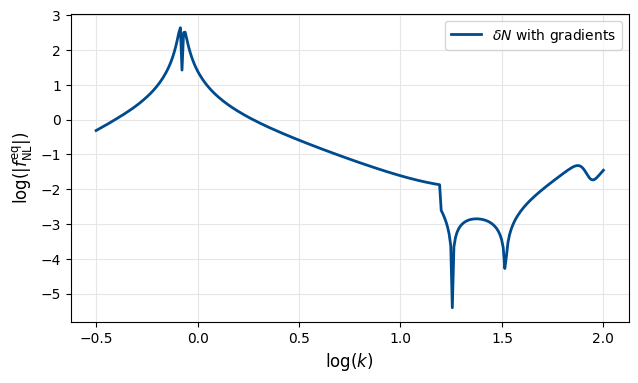

In [19]:
# ============================================================
# 7. Plotting Code
# ============================================================

# Variables for logging axes
log_k = np.log10(kk)
log_power_exact = np.log10(power_exact_array)
log_power_dN = np.log10(power_dN_array)
log_fNL = np.log10(np.abs(fNL_array))

# ---------- Figure 1: Power Spectrum Comparison ----------
plt.figure(figsize=(7.2, 4))

# Plot Exact Solution Line
plt.plot(log_k, log_power_exact, color='0.8', linewidth=4, zorder=1, label='Exact MS solution')

# Plot Full Gradient δN Solution Points
plt.plot(log_k, log_power_dN, linestyle='none', marker='.', 
         markeredgecolor='black', markersize=6, markerfacecolor='black', 
         zorder=2, label=r'$\delta N$ with full gradient interactions')

plt.xlabel(r'$\log(k)$', fontsize=12)
plt.ylabel(r'$\log(\mathcal{P}_{\mathcal{R}})$', fontsize=12)
plt.grid(True, which="both", ls="-", color='0.9', zorder=0)
plt.gca().set_axisbelow(True)

plt.legend(loc='upper left', fontsize=10, handlelength=3)

plt.savefig("power_spectrum_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# ---------- Figure 2: Non-Gaussianity f_NL ----------
plt.figure(figsize=(7.2, 4))

plt.plot(log_k, log_fNL, linestyle='solid', color='#004b8d', lw=2, 
         label=r'$\delta N$ with gradients')

plt.xlabel(r'$\log(k)$', fontsize=12)
plt.ylabel(r'$\log(|f_{\rm NL}^{\rm eq}|)$', fontsize=12)
plt.legend(loc='upper right', handlelength=2.2, fontsize=10)
plt.grid(True, which="both", ls="-", color='0.9')
plt.gca().set_axisbelow(True)

plt.savefig("fNL_comparison.png", dpi=300, bbox_inches="tight")
plt.show()